In [1]:
import glob
import numpy as np
import pandas as pd
import h5flow
import h5py
import matplotlib.pyplot as plt
import yaml

# import plotly.graph_objects as go
import matplotlib.cm as cm
import matplotlib
import matplotlib.lines as mlines

from h5flow.data import dereference
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.cm import ScalarMappable

from DrawEvent import *
from BiPoSelection import *

### Load Marjoleins results

In [ ]:
gf=1 # gate factor -> consistent with 1 according to Marjolein
s_gf=0

# =======================================================
# 1) Read the PDE CSV
# =======================================================

# path to results file (can get it from Marjolein)
df = pd.read_csv("PE_values_muons.csv")

# -------------------- ACL ------------------------------
df_acl = df[df["trap_name"].str.startswith("ACL ", na=False)].copy()

# Strip "ACL " (prefix + space) from trap_name → e.g. "ACL 4.24" → "4.24"
df_acl["trap_name_clean"] = df_acl["trap_name"].str.replace(r"^ACL\s+", "", regex=True)

trap_name_acl       = df_acl["trap_name_clean"].to_numpy()
det_id_acl          = df_acl["trap"].to_numpy()
tpc_acl             = df_acl["tpc"].to_numpy()
PE_meas_acl         = df_acl["PE_meas"].to_numpy()        / gf
PE_meas_noLTcr_acl  = df_acl["PE_meas_noLTcr"].to_numpy() / gf
PE_exp_acl          = df_acl["PE_exp"].to_numpy()
PE_exp_noLTcr_acl   = df_acl["PE_exp_noLTcr"].to_numpy()

# -------------------- LCM ------------------------------
df_lcm = df[df["trap_name"].str.startswith("LCM ", na=False)].copy()

def parse_lcm_numbers(name: str):
    """
    From 'LCM 49, 50, 51' or 'LCM 49,50,51' -> ['49', '50', '51']
    """
    rest = name.split(" ", 1)[1]  # part after 'LCM '
    rest = rest.replace(",", " ")
    parts = [p for p in rest.split() if p]
    return parts[:3]  # first up to 3 numbers

df_lcm = df_lcm.sort_values(["trap_name"]).copy()

def assign_lcm_labels(group):
    labels = parse_lcm_numbers(group.name)
    group = group.copy()
    for i, (idx, _) in enumerate(group.iloc[:len(labels)].iterrows()):
        group.loc[idx, "lcm_label"] = labels[i]
    return group

lcm_labeled = df_lcm.groupby("trap_name", group_keys=False).apply(
    assign_lcm_labels, include_groups=False
)
lcm_labeled = lcm_labeled.dropna(subset=["lcm_label"])

trap_name_lcm       = lcm_labeled["lcm_label"].to_numpy()
det_id_lcm          = lcm_labeled["trap"].to_numpy()
tpc_lcm             = lcm_labeled["tpc"].to_numpy()
PE_meas_lcm         = lcm_labeled["PE_meas"].to_numpy()        / gf
PE_meas_noLTcr_lcm  = lcm_labeled["PE_meas_noLTcr"].to_numpy() / gf
PE_exp_lcm          = lcm_labeled["PE_exp"].to_numpy()
PE_exp_noLTcr_lcm   = lcm_labeled["PE_exp_noLTcr"].to_numpy()


# =======================================================
# 2) Read the scan CSV
# =======================================================

# df_scan = pd.read_csv("sum_new_setup2.csv")
# df_scan = df_scan.dropna(subset=["Name"])

# # Extract the "4p16" part and turn it into "4.16"
# labeltag_scan = (
#     df_scan["Name"]
#     .str.extract(r'_(\d+p\d+)_')[0]  # "4p16"
#     .str.replace("p", ".", n=1)     # → "4.16"
#     .to_numpy()
# )

# PE_scan        = df_scan["p.e."].to_numpy()
# PE_uncert_scan = 6

# # Example sigma definition
# sigma_PE_scan = np.sqrt(PE_scan + (PE_scan * (PE_uncert_scan) / 100)**2)

# =======================================================
# 3) PDE & Uncertainties
# =======================================================

# ---------- ACL ----------

PDE_acl = np.divide(
    100 * PE_meas_acl,
    PE_exp_acl,
    out=np.zeros_like(PE_meas_acl, dtype=float),
    where=PE_exp_acl != 0
)

PDE_noLTcr_acl = np.divide(
    100 * PE_meas_noLTcr_acl,
    PE_exp_noLTcr_acl,
    out=np.zeros_like(PE_meas_noLTcr_acl, dtype=float),
    where=PE_exp_noLTcr_acl != 0
)

# Relative variances
rel_var_meas_acl = np.divide(
    1.0 / PE_meas_acl,
    1.0,
    out=np.zeros_like(PE_meas_acl, dtype=float),
    where=PE_meas_acl > 0
)

rel_var_gain = 0.20**2        # 20% gain uncertainty
rel_var_exp  = 0.10**2        # 10% PE_exp uncertainty

# Total uncertainty on PDE
sigma_PDE_acl = np.abs(PDE_acl) * np.sqrt(
    rel_var_meas_acl + rel_var_gain + rel_var_exp
)

rel_var_meas_noLTcr_acl = np.divide(
    1.0 / PE_meas_noLTcr_acl,
    1.0,
    out=np.zeros_like(PE_meas_noLTcr_acl, dtype=float),
    where=PE_meas_noLTcr_acl > 0
)
sigma_PDE_noLTcr_acl = np.abs(PDE_noLTcr_acl) * np.sqrt(
    rel_var_meas_acl + rel_var_gain + rel_var_exp
)


# ---------- LCM ----------
PDE_lcm = np.divide(
    100 * PE_meas_lcm,
    PE_exp_lcm,
    out=np.zeros_like(PE_meas_lcm, dtype=float),
    where=PE_exp_lcm != 0
)

PDE_noLTcr_lcm = np.divide(
    100 * PE_meas_noLTcr_lcm,
    PE_exp_noLTcr_lcm,
    out=np.zeros_like(PE_meas_noLTcr_lcm, dtype=float),
    where=PE_exp_noLTcr_lcm != 0
)


# Relative variances
rel_var_meas_lcm = np.divide(
    1.0 / PE_meas_lcm,
    1.0,
    out=np.zeros_like(PE_meas_lcm, dtype=float),
    where=PE_meas_lcm > 0
)

rel_var_gain = 0.20**2        # 20% gain uncertainty
rel_var_exp  = 0.10**2        # 10% PE_exp uncertainty

# Total uncertainty on PDE
sigma_PDE_lcm = np.abs(PDE_lcm) * np.sqrt(
    rel_var_meas_lcm + rel_var_gain + rel_var_exp
)

rel_var_meas_noLTcr_lcm = np.divide(
    1.0 / PE_meas_noLTcr_lcm,
    1.0,
    out=np.zeros_like(PE_meas_noLTcr_lcm, dtype=float),
    where=PE_meas_noLTcr_lcm > 0
)
sigma_PDE_noLTcr_lcm = np.abs(PDE_noLTcr_lcm) * np.sqrt(
    rel_var_meas_lcm + rel_var_gain + rel_var_exp
)

Function to calculate the solid angle and the PDE

In [ ]:
# this gives the solid angle of a rectangle with corners (x0, x1, y0, y1) 
# at a position z_det, as seen from a point (x_s, y_s, z_s)
# The corners you can get from the geometry branch that is in the hdf5 files


def solid_angle_rectangle(x_s, y_s, z_s, x0, x1, y0, y1, z_det):
    z = np.abs(z_det - z_s)
    omega = 0.0
    for i, xi in enumerate([x0, x1]):
        for j, yj in enumerate([y0, y1]):
            sign = (-1) ** (i + j)
            dx = xi - x_s
            dy = yj - y_s
            r = np.sqrt(dx**2 + dy**2 + z**2)
            if z != 0:
                omega += sign * np.arctan((dx * dy) / (z * r))
    return omega




def compute_light_fraction_from_point_deposition(
    xcluster, ycluster, zcluster, x0, x1, y0, y1, z_det):
    """
    Compute expected light for a rectangular detector from a pre-defined
    straight track, given by segment midpoints and lengths, using:
       
       N_gamma = Y_gamma * exp(-d/3000)

    where d is the 3D distance from the segment midpoint to the center of the
    lighttrap rectangle (at z_det).

    Returns
    -------
    total_detected, total_produced, fraction_detected
    """
    # Constants
    # Y_gamma = 24000  # photons per MeV at 500 V/cm
    # dEdx_muon = 2.1  # MeV/cm, MIP energy loss in LAr

    E_alpha = 9.0
    Y_gamma = 30500.0  # photons per MeV at 500 V/cm for alpha (check this)
    att_len = 3000.0  # cm

    total_produced = 0.0
    total_detected = 0.0

    # center of the light trap rectangle (at plane z_det)
    xc = 0.5 * (x0 + x1)
    yc = 0.5 * (y0 + y1)
    zc = z_det


    # distance from emission point to trap center
    dist = np.sqrt((xcluster - xc) ** 2 + (ycluster - yc) ** 2 + (zcluster - zc) ** 2)


    

    # photons produced by alpha with 9 MeV with exponential reduction
    N_gamma = E_alpha * Y_gamma * np.exp(-dist / att_len)
    total_produced = N_gamma

    # solid angle from the cluster to the rectangle
    omega = solid_angle_rectangle(xcluster, ycluster, zcluster, x0, x1, y0, y1, z_det)
    if omega < 0:
        omega = 0.0

    frac = omega / (4 * np.pi)
    total_detected = frac * N_gamma

    fraction = total_detected / total_produced if total_produced > 0 else 0.0


    return total_detected, total_produced, fraction, dist




# calculate the PDE for one hit
def compute_pde_hit(integral, xcluster, ycluster, zcluster, x0, x1, y0, y1, z_det):
    
    total_detected, total_produced, fraction, dist = compute_light_fraction_from_point_deposition(
    xcluster, ycluster, zcluster, x0, x1, y0, y1, z_det)

    pde = integral / total_detected

    return pde, total_detected, total_produced, fraction, dist

Functions to get the clusters and alpah hits

In [ ]:
# return the charge information
def get_clusters_for_light_event(light_event, CL_data, lid_to_idx):
    """
    light_event is light event number from a run
    CL data: files with the light events and the corresponding matched clusters
    lid_to_idx is the array that gives the index in of a given light event in the CL_file arrays"""
    d_i     = lid_to_idx[light_event]
    first = CL_data['first_cl'][d_i]
    n     = CL_data['num_cl'][d_i]
    sl    = np.arange(first, first + n, dtype=np.int64)

    return {
        'x_rec':     CL_data['cluster_x_rec'][sl],
        'x_anode':   CL_data['cluster_x_anode'][sl],
        'y':         CL_data['cluster_y'][sl],
        'z':         CL_data['cluster_z'][sl],
        'charge_id': CL_data['cluster_charge_id'][sl],
    }


# get the light information for an alpha hit (in one event)
def get_alpha_hits(EVENT, hit1, hit2, sum_tpc_hits, sum_hits):
    """
    hit_pairs: hits in the same waveform
    light_events: light events that are BiPo selected (and have only one cluster)
    particle: alpha or beta
    sum_hits: summed channel hits (detector hit)

    """
    beta_hits = []
    alpha_hits = []

    # get the det hits in the event
    events, det_hits, det_hits_per_event  = np.unique(sum_hits['refs'][:,0],
                                              return_index=True,
                                              sorted=False,
                                              return_counts=True)
    first_det_hit_in_event = det_hits[EVENT]
    num_det_hits_in_event = det_hits_per_event[EVENT]
    
    det_hits_in_event = np.arange(first_det_hit_in_event, 
                                first_det_hit_in_event+num_det_hits_in_event, dtype=np.int64)
    

    # tick index of first and second hit
    t1 = sum_tpc_hits['sample_idx'][hit1]
    t2 = sum_tpc_hits['sample_idx'][hit2]


    # Get sample indices of the sum_hits
    ticks = sum_hits['sample_idx'][det_hits_in_event]

    # calculate the distance of det_hit to the first and second hit in a hit pair 
    dist_to_h1 = np.abs(ticks - t1)
    dist_to_h2 = np.abs(ticks - t2)


    beta_mask = (dist_to_h1 <= dist_to_h2)   # does the equal sign make sense here?
    alpha_mask = (dist_to_h2 < dist_to_h1) 

    beta_hits = det_hits_in_event[beta_mask]
    alpha_hits = det_hits_in_event[alpha_mask]

    return beta_hits, alpha_hits



Function make the distribution of the PDEs and find the fwhm 

In [15]:
def find_fwhm(data, bins):
    hist, bins = np.histogram(data, bins=bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    # find the x value with the max counts
    max_bin = np.argmax(hist)

    # max height and half height
    max_height = hist[max_bin]
    half_height = 0.5 * max_height

    # find the first bin below half height to the left
    height_left = max_height
    index_left = max_bin
    while height_left > half_height:
        height_left = hist[index_left]
        index_left = index_left - 1

    # find the first bin below half height to the right
    height_right = max_height
    index_right = max_bin
    while height_right > half_height:
        height_right = hist[index_right]
        index_right = index_right + 1

    mpv = bin_centers[max_bin]
    fwhm = bins[index_right-1] - bins[index_left+2]

    error_left = mpv - bins[index_left+2]
    error_right = bins[index_right-1] - mpv

    return mpv, fwhm, error_left, error_right, max_height

Get the geometry

In [5]:
def get_plate_xyz(det_id, tpc_shift, geom_dict):    
    shape_key = 0 if (det_id % 4) == 0 else 1 #Didnt have a better plan, but we know ACLs are every modulo 4 
    offs_min  = np.array(geom_dict['geom'][shape_key]['min'], float)
    offs_max  = np.array(geom_dict['geom'][shape_key]['max'], float)

    xmin,ymin,_ = offs_min
    xmax,ymax,_ = offs_max
    
    det_ctr_local = np.array(geom_dict['det_center'][det_id], float) # relative position of det on tpc

    x0 = xmin + det_ctr_local[0] + tpc_shift[0]
    x1 = xmax + det_ctr_local[0] + tpc_shift[0]
    y0 = ymin + det_ctr_local[1] + tpc_shift[1]
    y1 = ymax + det_ctr_local[1] + tpc_shift[1]
    z_det = 0 + det_ctr_local[2] + tpc_shift[2]

    
    return [x0, x1], [y0, y1], z_det

# --- GEOMETRY ---
#We can load the detector center position and the SiPM position from the geometry 
lrs_geometry_file = '/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow/data/proto_nd_flow/light_module_desc-5.0.1.yaml'
with open(lrs_geometry_file) as gf:
    lrs_geometry_yaml = yaml.load(gf, Loader=yaml.FullLoader)

tpc_ids =  np.array([v for v in lrs_geometry_yaml['tpc_center_offset'].keys()])
det_ids = np.array([v for v in lrs_geometry_yaml['det_center'].keys()])


det_type_array = np.zeros((len(tpc_ids), len(det_ids)), dtype=np.int32)
for i, tpc in enumerate(tpc_ids):
    for j, det in enumerate(det_ids):
        det_type = lrs_geometry_yaml['det_geom'][tpc][det]
        det_type_array[i,j] = det_type

CL_775_p1 = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_CLmatching_low_energy/flowed_light_low_energy_v3/source_rn_bin1/injection/packet-0060156-2025_11_20_20_06_56_CST_mpd_run_data_rctl_775_p1_CLmatched.FLOW_LE.hdf5'
tpc_bounds = extract_tpc_bounds(h5py.File(CL_775_p1))

Function to process one run

In [ ]:
# combine all the previous functions to calculate the PDE for all BiPo alpha in one run
def get_pdes_per_run(tpc_hit_data, det_hit_data, d,
                     tpc_bounds,lrs_geometry_yaml,
                     hit_pairs, events_with_nhits, selected_ids, light_id_to_idx):
    # get the hit pairs for the selected light ids
    i = 0
    cur_event = -1

    # prepare arrays/lists to store the information
    pdes = np.full((len(selected_ids), 8,16), 
                        fill_value=np.nan, dtype=np.float64) # array filled with -1, shape [n_events, tpcs, dets]
    distances = np.full((len(selected_ids), 8,16), 
                        fill_value=np.nan, dtype=np.float64) # array filled with -1, shape [n_events, tpcs, dets]
    total_detected = np.full((len(selected_ids), 8,16), 
                        fill_value=np.nan, dtype=np.float64) # array filled with -1, shape [n_events, tpcs, dets]
    total_produced = np.full((len(selected_ids), 8,16), 
                        fill_value=np.nan, dtype=np.float64) # array filled with -1, shape [n_events, tpcs, dets]
    total_integral = np.full((len(selected_ids), 8,16), 
                        fill_value=np.nan, dtype=np.float64) # array filled with -1, shape [n_events, tpcs, dets]
    
    
    all_cluster_locationsx = []
    all_cluster_locationsy = []
    all_cluster_locationsz = []

    # loop through all the pairs 
    for pair, event in zip(hit_pairs, events_with_nhits):
        # if one event has multiple pairs only need to look at it once
        if cur_event==event:
            continue

        elif event in selected_ids:
            # get the alpha hits in the event 
            beta_hits, alpha_hits = get_alpha_hits(EVENT=event, 
                        hit1=pair[0], hit2=pair[1], 
                        sum_tpc_hits=tpc_hit_data, 
                        sum_hits=det_hit_data) 

            # get the integral of the alpha hits and store it in a np array (16 channels, 0 if no hit)
            integrals = np.zeros(16, dtype=np.float64)
            
            for h in alpha_hits:
                det_id   = det_hit_data['det'][h] 
                integrals[det_id] = det_hit_data['integral'][h] # lets only keep one for now because light is likely included in the first one from the second
    

            # get the tpc of hits (light)
            d_idx = light_id_to_idx[event]
            tpc_light = d['tpc'][d_idx][0]


            ### CHARGE CLUSTER
            # get the coordinates from the cluster 
            cl_results = get_clusters_for_light_event(light_event=event, CL_data=d, lid_to_idx=light_id_to_idx)
            xcluster = cl_results['x_rec']
            ycluster = cl_results['y']
            zcluster = cl_results['z']

            # just to double check if there is multiple clusters matched
            if len(xcluster) > 1:
                continue
            
            # get the tpc of the charge based on the reconstructed position
            tpc_charge = get_tpc_from_xz(xcluster, zcluster, tpc_bounds)

            if tpc_light != tpc_charge:
                continue 
            
            # calculate the PDE
            bounds = tpc_bounds[tpc_light]
            tpc_shift = np.mean(bounds, axis=0)
            

            # store the position of the cluster
            all_cluster_locationsx.append(xcluster[0])
            all_cluster_locationsy.append(ycluster[0])
            all_cluster_locationsz.append(zcluster[0])



            for det_id in sorted(lrs_geometry_yaml['det_center'].keys(), key=int):
                # position of the corners of det d on tpc t
                x, y, z_det = get_plate_xyz(int(det_id), tpc_shift, lrs_geometry_yaml)
                integral = integrals[det_id] / 4 # diving by 4 again because of the gain (should be done somewhere else)

                pde, detected, produced, fraction, dist = compute_pde_hit(
                    integral, xcluster[0], ycluster[0], zcluster[0], x[0], x[1], y[0], y[1], z_det)
                
                pdes[i][tpc_light][det_id] = pde
                distances[i][tpc_light][det_id] = dist
                total_detected[i][tpc_light][det_id] = detected
                total_produced[i][tpc_light][det_id] = produced
                total_integral[i][tpc_light][det_id] = integral


                if pde > 1:
                    print('Event ', event, 'alphahits ', alpha_hits)
                    print('PDE', pde, 'Integral', integral, 'Det', det_id, 'd', dist)
                    # print('Light tpc', tpc_light, 'Charge tpc', tpc_charge)

                    
            i += 1

        cur_event = event

        
    return pdes, distances, total_detected, total_produced, total_integral, all_cluster_locationsx, all_cluster_locationsy, all_cluster_locationsz



Files that are used 

In [ ]:
CL_path = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_CLmatching_low_energy/flowed_light_low_energy_v3/source_rn_bin1/injection/'
# light files
light_path = '/global/cfs/cdirs/dune/users/mlopuszanski/Rn_injection/results/'

# usage — just provide the names
run_i = list(range(1, 21)) + list(range(120, 141)) + list(range(241, 260))
run_names = [f'rctl_775_p{i}' for i in run_i]  # p1 to p5

runs = build_runs(run_names, CL_path, light_path)
print(f'Found {len(runs)} complete runs')


CL_file = f'processed_files/CL_{runs[0]["name"]}.npz'
sum_light_file = runs[0]['sum_light']
tpc_light_file = runs[0]['tpc_light']


Found 60 complete runs
dict_keys(['name', 'CL', 'sum_light', 'tpc_light'])


Process files and calculate the PDE (this takes a few minutes to run)

It would make sense to store the PDE results also in a file

In [9]:
runsss=runs[:]
CL_matched_files = [f'processed_files/CL_{run["name"]}.npz' for run in runsss]
hit_data_tpc_files = [f'{run["tpc_light"]}' for run in runsss]
hit_data_sum_files = [f'{run["sum_light"]}' for run in runsss]

all_pdes, all_distances = [], []
all_detected, all_produced, all_integrals = [], [], []
allx, ally, allz = [], [], []
for CL_file, tpc_light_file, sum_light_file in zip(CL_matched_files, hit_data_tpc_files, hit_data_sum_files):
    # --- load files ---
    CL_data = np.load(CL_file, allow_pickle=True)
    light_id_to_idx = {lid: i for i, lid in enumerate(CL_data['light_id'])}

    tpc_hit_data = np.load(tpc_light_file, 
                    allow_pickle=True).item() 

    hit_pairs, events_with_nhits, dt_list = calculate_dt(tpc_hit_data, tpc_hit_data['refs'], tpc_or_ch_sum='tpc')
    print(f'Found {len(hit_pairs)} light events with multiple hits in one wvfm')

    det_hit_data = np.load(sum_light_file, 
                    allow_pickle=True).item() 
    
    # --- selection ---
    mask = CL_data['is_bipo'] & (CL_data['num_cl'] == 1)

    # BiPo events with a single cluster
    selected_ids = CL_data['light_id'][mask]

    # apply single tpc mask here 
    single_tpc_mask = np.array([
            len(CL_data['tpc'][light_id_to_idx[lid]]) == 1
            for lid in selected_ids
        ])
    # BiPo events, single cluster, single TPC
    selected_ids = selected_ids[single_tpc_mask]  # stays a numpy array, ordered


    pdes, distances, total_detected, total_produced, total_integral, xcl, ycl, zcl = get_pdes_per_run(tpc_hit_data, det_hit_data, CL_data,
                     tpc_bounds,lrs_geometry_yaml,
                     hit_pairs, events_with_nhits, selected_ids, light_id_to_idx)
    
    all_pdes.append(pdes)
    all_distances.append(distances)
    all_detected.append(total_detected)
    all_produced.append(total_produced)
    all_integrals.append(total_integral)

    # get just the cluster location for cross checks 
    allx.append(xcl)
    ally.append(ycl)
    allz.append(zcl)


all_pdes=np.concatenate(all_pdes)
all_distances=np.concatenate(all_distances)
all_detected=np.concatenate(all_detected)
all_produced=np.concatenate(all_produced)
all_integrals=np.concatenate(all_integrals)
allx=np.concatenate(allx)
ally=np.concatenate(ally)
allz=np.concatenate(allz)



Found 489 light events with multiple hits in one wvfm
Found 469 light events with multiple hits in one wvfm
Event  1630 alphahits  [7820 7821 7822 7823 7825 7826]
PDE 2.3289176143779318 Integral 13.059721946716309 Det 15 d 114.30633730355973
Found 475 light events with multiple hits in one wvfm
Found 475 light events with multiple hits in one wvfm
Found 459 light events with multiple hits in one wvfm
Found 481 light events with multiple hits in one wvfm
Found 492 light events with multiple hits in one wvfm
Found 519 light events with multiple hits in one wvfm
Found 441 light events with multiple hits in one wvfm
Found 480 light events with multiple hits in one wvfm
Found 442 light events with multiple hits in one wvfm
Found 465 light events with multiple hits in one wvfm
Found 444 light events with multiple hits in one wvfm
Found 473 light events with multiple hits in one wvfm
Found 454 light events with multiple hits in one wvfm
Event  6210 alphahits  [29616 29618 29619 29620 29621 29

### Plotting the PDE results of muons and alphas

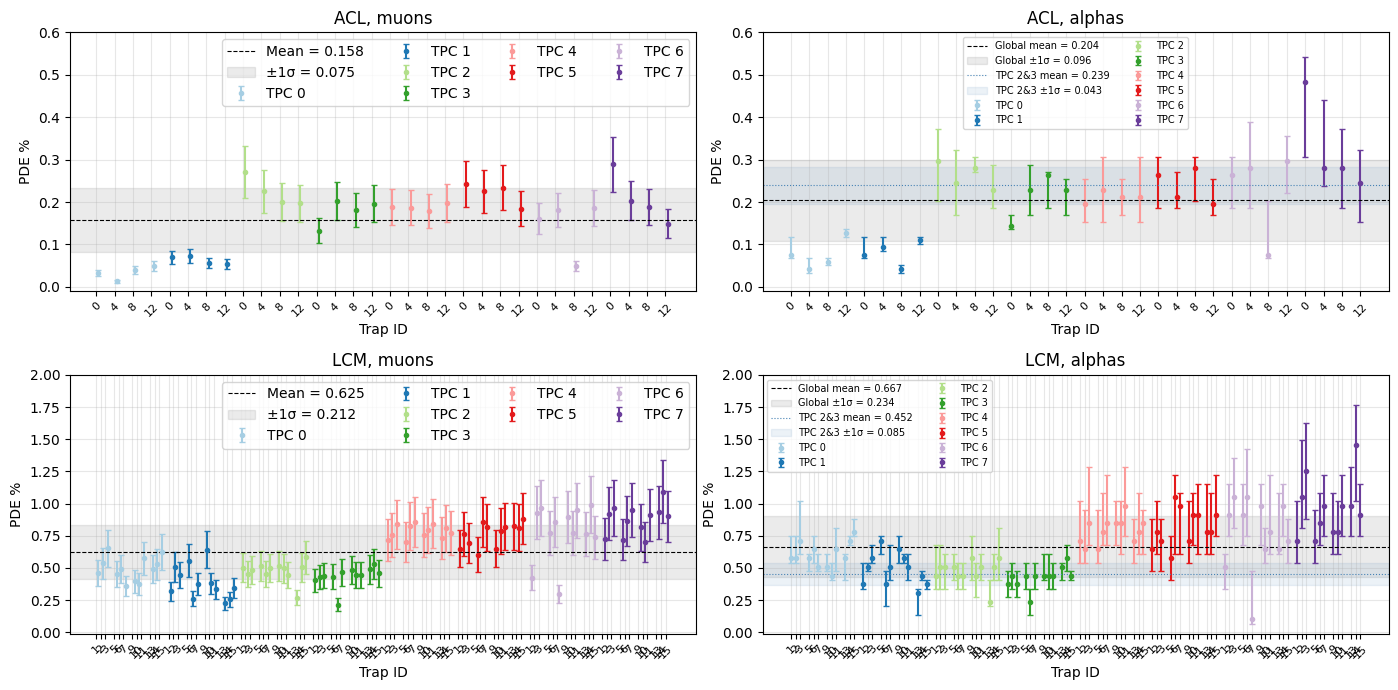

In [ ]:
mask_acl = det_type_array == 0
mask_lcm = det_type_array == 1
mask0 = (all_pdes != 0.0) & (~np.isnan(all_pdes))
pdes_masked = np.where(mask0, all_pdes * 100, np.nan)

fig, axes = plt.subplots(2,2, figsize=(14, 7))
axes = axes.flatten()
colors = [matplotlib.color_sequences['Paired'][i] for i in [0,1,2,3,4,5,8,9]]

mpv_pdes_acl, mpv_pdes_lcm, mpv_pdes_group_lcm= [], [], []
fwhm_pdes_acl, fwhm_pdes_lcm, fwhm_pdes_group_lcm = [], [], []
error_lr_pdes_acl, error_lr_pdes_lcm, error_lr_pdes_group_lcm = [], [], []
# Track mpv values per TPC for axes[1] and axes[3]
mpv_pdes_acl_per_tpc = {tpc_id: [] for tpc_id in range(8)}
mpv_pdes_lcm_per_tpc = {tpc_id: [] for tpc_id in range(8)}

for tpc_id in np.arange(0,8,1):
    label = f'TPC {tpc_id}'
    color = colors[tpc_id]

    ax = axes[0]
    ax.errorbar(det_id_acl[tpc_id]+16*tpc_id + 0.5, PDE_noLTcr_acl[tpc_id], 
                yerr=sigma_PDE_noLTcr_acl[tpc_id],
                fmt='o', markersize=3, capsize=2, 
                color=color, label=label # ({n_valid[tpc_id][mask_acl[tpc_id]]})
            )

    ax = axes[2]
    ax.errorbar(det_id_lcm[tpc_id]+16*tpc_id + 0.5, PDE_noLTcr_lcm[tpc_id], 
                yerr=sigma_PDE_noLTcr_lcm[tpc_id],
                fmt='o', markersize=3, capsize=2, 
                color=color, label=label # ({n_valid[tpc_id][mask_acl[tpc_id]]})
            )
    
    for det_id in range(16): 
        vals = pdes_masked[:, tpc_id, det_id]
        vals = vals[~np.isnan(vals)]
        
        if det_id in [0, 4, 8 , 12]:
            bins=np.linspace(0, 1, 60)
            mpv, fwhm, error_left, error_right, _ = find_fwhm(vals, bins=bins)
            error = [[error_left], [error_right]]
            ax = axes[1]
            mpv_pdes_acl.append(mpv)
            mpv_pdes_acl_per_tpc[tpc_id].append(mpv)
            error_lr_pdes_acl.append(error)
            fwhm_pdes_acl.append(fwhm)
        else:
            bins=np.linspace(0, 4, 60)
            mpv, fwhm, error_left, error_right, _ = find_fwhm(vals, bins=bins)
            error = [[error_left], [error_right]]
            ax = axes[3]
            mpv_pdes_lcm.append(mpv)
            mpv_pdes_lcm_per_tpc[tpc_id].append(mpv)
            error_lr_pdes_lcm.append(error)
            fwhm_pdes_lcm.append(fwhm)

        if det_id in [0, 1]:
            label = f'TPC {tpc_id}'
        else: label = None
        
        ax.errorbar(
            det_id+16*tpc_id, mpv, 
            yerr=error,
            fmt='o', markersize=3, capsize=2, 
            color=color, label=label # ({n_valid[tpc_id][mask_acl[tpc_id]]})
        )


for ax, title in zip(axes, ['ACL, muons', 'ACL, alphas', 'LCM, muons', 'LCM, alphas']):
   
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # set xticks to actual det_id values with tpc offset, labelled as "TPC X - det Y"
    tick_positions = []
    tick_labels = []
    for tpc_id in np.arange(0,8,1):
        dets = det_ids[mask_acl[tpc_id]] if ax == axes[0] or ax == axes[1] else det_ids[mask_lcm[tpc_id]]
        for d in dets:
            tick_positions.append(d + tpc_id * 16)
            # tick_labels.append(f'{tpc_id}, {d}')
            tick_labels.append(f'{d}')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45)
    ax.set_ylabel('PDE %')
    ax.set_xlabel('Trap ID')

axes[0].legend(ncols=4)
axes[1].legend(ncols=4)
axes[0].set_ylim(-0.01, 0.6)
axes[1].set_ylim(-0.01, 0.6)
axes[2].set_ylim(-0.01, 2)
axes[3].set_ylim(-0.01, 2)

    

# plot the mean
# --- axes[0] and axes[2]: mean ± std from PDE_noLTcr arrays ---
for ax, arr, label_prefix in [
    (axes[0], PDE_noLTcr_acl, 'ACL muons'),
    (axes[2], PDE_noLTcr_lcm, 'LCM muons'),
]:
    flat = np.concatenate([np.atleast_1d(a) for a in arr])
    flat = flat[~np.isnan(flat)]
    mean_val = np.nanmean(flat)
    std_val  = np.nanstd(flat)
    ax.axhline(mean_val, color='black', linewidth=0.8, linestyle='--',
               label=f'Mean = {mean_val:.3f}')
    ax.axhspan(mean_val - std_val, mean_val + std_val,
               color='black', alpha=0.08, label=f'±1σ = {std_val:.3f}')
    ax.legend(ncols=4)


# --- axes[1] and axes[3]: global mean/std + TPC 2&3 mean/std ---
for ax, mpv_list, mpv_per_tpc, label_prefix in [
    (axes[1], mpv_pdes_acl, mpv_pdes_acl_per_tpc, 'ACL alphas'),
    (axes[3], mpv_pdes_lcm, mpv_pdes_lcm_per_tpc, 'LCM alphas'),
]:
    # Global mean ± std
    global_vals = np.array(mpv_list)
    global_vals = global_vals[~np.isnan(global_vals)]
    g_mean = np.nanmean(global_vals)
    g_std  = np.nanstd(global_vals)
    ax.axhline(g_mean, color='black', linewidth=0.8, linestyle='--',
               label=f'Global mean = {g_mean:.3f}')
    ax.axhspan(g_mean - g_std, g_mean + g_std,
               color='black', alpha=0.08, label=f'Global ±1σ = {g_std:.3f}')

    # TPC 2 & 3 mean ± std
    tpc23_vals = np.array(mpv_per_tpc[2] + mpv_per_tpc[3])
    tpc23_vals = tpc23_vals[~np.isnan(tpc23_vals)]
    t_mean = np.nanmean(tpc23_vals)
    t_std  = np.nanstd(tpc23_vals)
    ax.axhline(t_mean, color='steelblue', linewidth=0.8, linestyle=':',
               label=f'TPC 2&3 mean = {t_mean:.3f}')
    ax.axhspan(t_mean - t_std, t_mean + t_std,
               color='steelblue', alpha=0.10, label=f'TPC 2&3 ±1σ = {t_std:.3f}')

    ax.legend(ncols=2, fontsize=7)


fig.tight_layout()
plt.show()

In [ ]:
# calculate averages:

for mpv in [mpv_pdes_acl, mpv_pdes_lcm]:
    print(f'{np.average(mpv):.4} +- {np.std(mpv):.4}')


0.2044 +- 0.09569
0.6667 +- 0.2342
nan +- nan


/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid va

#### Plotting muon vs alpha PDE

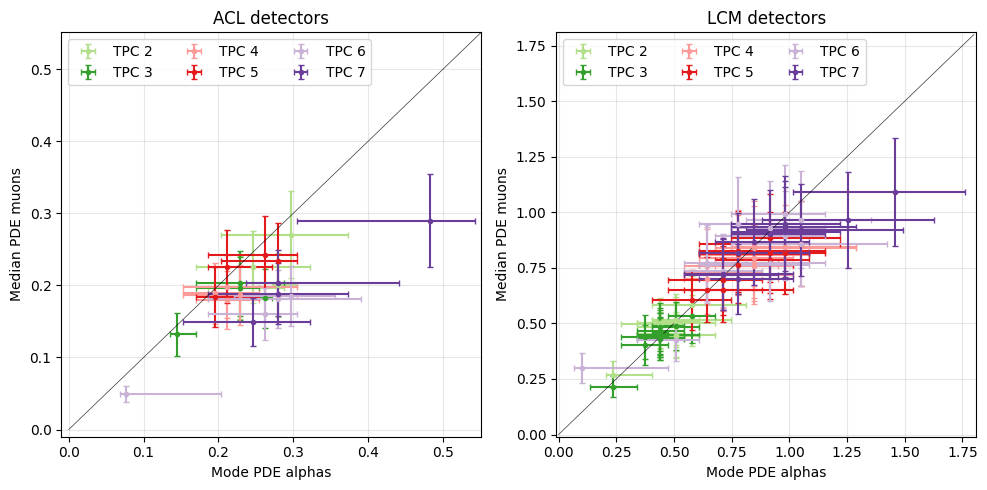

In [59]:
mean_pdes_acl = np.array(mpv_pdes_acl).reshape(8, 4)
error_pdes_acl = np.array(error_lr_pdes_acl).reshape(8, 4, 2)
mean_pdes_lcm = np.array(mpv_pdes_lcm).reshape(8, 12)
error_pdes_lcm = np.array(error_lr_pdes_lcm).reshape(8, 12, 2)

fig, axes = plt.subplots(1,2, figsize=(10, 5))
axes = axes.flatten()
colors = [matplotlib.color_sequences['Paired'][i] for i in [0,1,2,3,4,5,8,9]]

for tpc_id in np.arange(2,8,1):
    label=f'TPC {tpc_id}'

    ax = axes[0]
    ax.errorbar(mean_pdes_acl[tpc_id], PDE_noLTcr_acl[tpc_id], 
                xerr=error_pdes_acl[tpc_id].T,
                yerr=sigma_PDE_noLTcr_acl[tpc_id],
                fmt='o', markersize=3, capsize=2, 
                color=colors[tpc_id], label=label # ({n_valid[tpc_id][mask_acl[tpc_id]]})
            )


    ax = axes[1]
    ax.errorbar(mean_pdes_lcm[tpc_id], PDE_noLTcr_lcm[tpc_id], 
                xerr=error_pdes_lcm[tpc_id].T,
                yerr=sigma_PDE_noLTcr_lcm[tpc_id],
                fmt='o', markersize=3, capsize=2, 
                color=colors[tpc_id], label=label # ({n_valid[tpc_id][mask_acl[tpc_id]]})
            )

axes[0].plot([0,0.55], [0,0.55], color='black', alpha=0.8, lw=0.5)
axes[1].plot([0,1.8], [0,1.8], color='black', alpha=0.8, lw=0.5)
for ax, title in zip(axes, ['ACL detectors', 'LCM detectors']):
    ax.set_ylabel('Median PDE muons')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', ncols=3)
    ax.set_xlabel('Mode PDE alphas')

axes[0].set_ylim(-0.01, 0.551)
axes[0].set_xlim(-0.01, 0.551)
axes[1].set_ylim(-0.01, 1.81)
axes[1].set_xlim(-0.01, 1.81)


fig.tight_layout()
plt.show()

### Plotting the distributions of alpha derived PDEs

For each trap

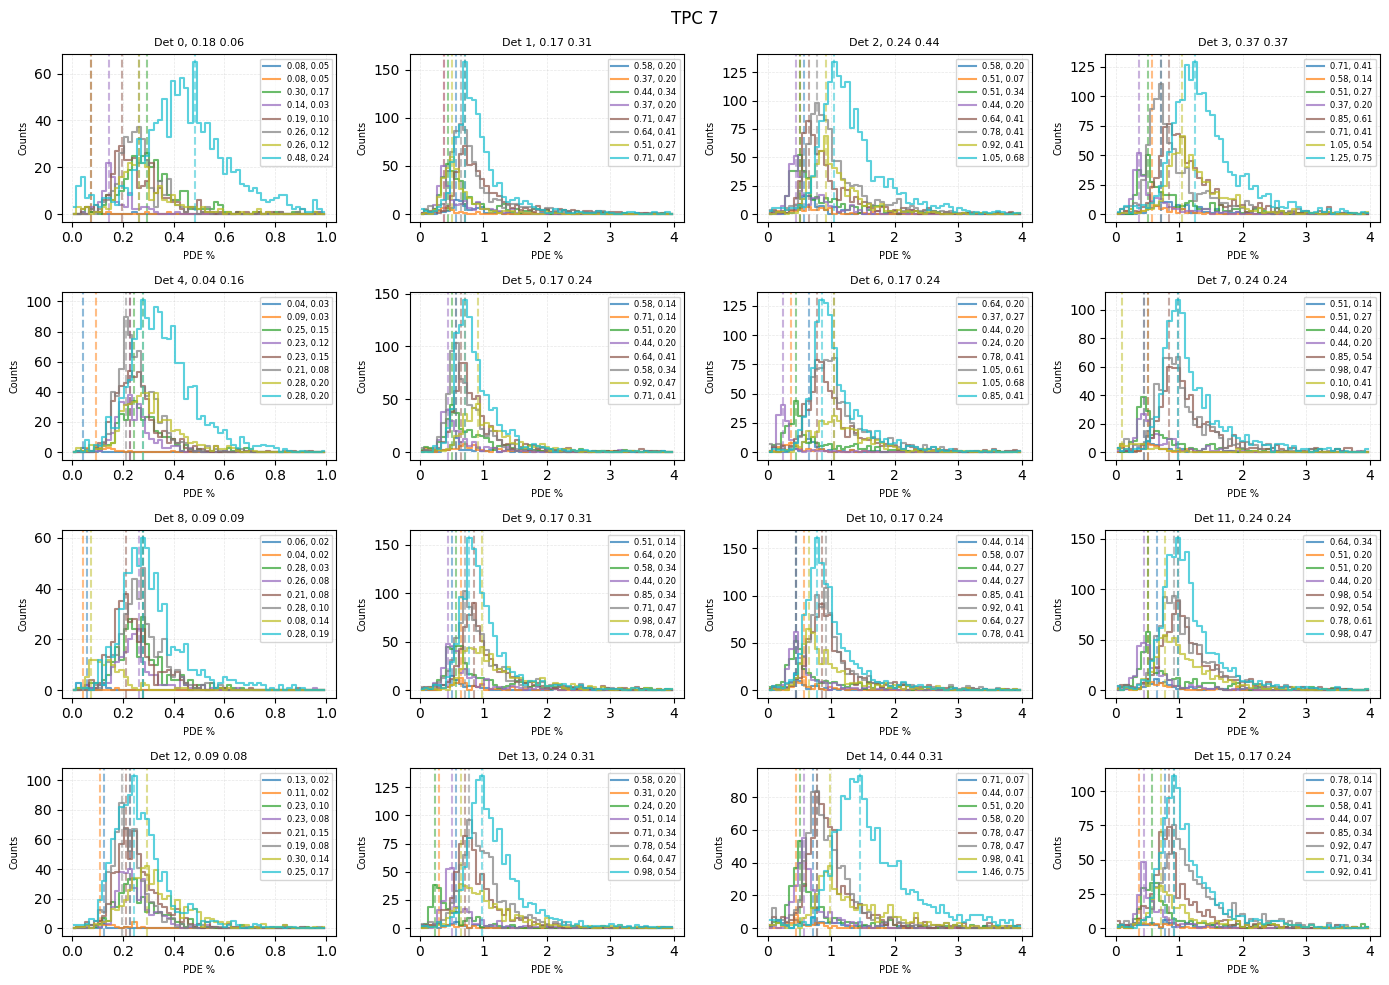

In [20]:
mask_acl = det_type_array == 0
mask_lcm = det_type_array == 1
mask0 = (all_pdes != 0.0) & (~np.isnan(all_pdes))
dist_masked = np.where(mask0, all_pdes * 100, np.nan)

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()
for tpc_id in range(8):
    for det_id in range(16):
        if det_id in [0, 4, 8 , 12]:
            bins=np.linspace(0, 1, 60)
        else:
            bins=np.linspace(0, 4, 60)

        vals = dist_masked[:, tpc_id, det_id]
        vals = vals[~np.isnan(vals)]
        max_height, fwhm, error_left, error_right, _ = find_fwhm(vals, bins=bins)
        
        # label = 'ACL' if mask_acl[tpc_id, det_id] else 'LCM'
        label = f'{max_height:.2f}, {fwhm:.2f}'
        
        draw_hist(axes[det_id], vals, bins=bins,
                  label=label, color=colors[tpc_id])
        
        
        axes[det_id].axvline(max_height, color=colors[tpc_id], alpha=0.5, linestyle='--')
        axes[det_id].set_title(f'Det {det_id}, {error_left:.2f} {error_right:.2f}', fontsize=8)
        axes[det_id].legend(fontsize=6)
        axes[det_id].grid(True, alpha=0.3)
        axes[det_id].set_xlabel('PDE %', fontsize=7)
        axes[det_id].set_ylabel('Counts', fontsize=7)

fig.suptitle(f'TPC {tpc_id}', fontsize=12)
fig.tight_layout()
plt.show()



Per traptype

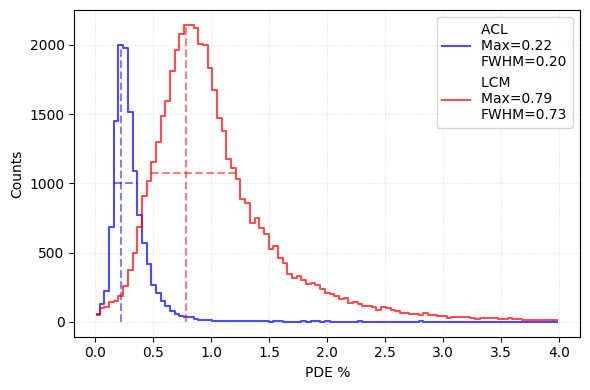

In [12]:
vals_acl, vals_lcm = [], []

for tpc_id in range(8):
    for det_id in det_ids:
        vals = all_pdes[:, tpc_id, det_id]
        vals = vals[~np.isnan(vals)]
        if det_id in [0, 4, 8, 12]:
            vals_acl.append(vals)
        else:
            vals_lcm.append(vals)



vals_acl = np.concatenate(vals_acl)*100
vals_lcm = np.concatenate(vals_lcm)*100


fig, ax = plt.subplots(1,1,figsize=(6, 4))


mask = vals_acl !=0
mpv, fwhm, error_left, error_right, max_height = find_fwhm(vals_acl[mask], bins=np.linspace(0, 4, 100))      
# label = 'ACL' if mask_acl[tpc_id, det_id] else 'LCM'
label = f'Max={mpv:.2f} \nFWHM={fwhm:.2f}'
draw_hist(ax, vals_acl[mask], bins=np.linspace(0,4,100), 
                label=f'ACL \n{label}',
                color='blue'
                )
ax.vlines(mpv, ymin=0, ymax=max_height, color='blue', linestyle='--', alpha=0.5)
ax.hlines(0.5*max_height, xmin=mpv-error_left, xmax=mpv + error_right, color='blue', linestyle='--', alpha=0.5)


mask = vals_lcm !=0
mpv, fwhm, error_left, error_right, max_height = find_fwhm(vals_lcm[mask], bins=np.linspace(0, 4, 100))      
# label = 'ACL' if mask_acl[tpc_id, det_id] else 'LCM'
label = f'Max={mpv:.2f} \nFWHM={fwhm:.2f}'
draw_hist(ax, vals_lcm[mask], bins=np.linspace(0,4,100), 
                label=f'LCM \n{label}',
                color='red'
                )
# ax.axvline(mpv - error_left, color='blue', linestyle=':', alpha=0.8)
# ax.axvline(mpv + error_right, color='blue', linestyle=':', alpha=0.8)
ax.vlines(mpv, ymin=0, ymax=max_height, color='red', linestyle='--', alpha=0.5)
ax.hlines(0.5*max_height, xmin=mpv-error_left, xmax=mpv + error_right, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('PDE %')
ax.set_ylabel('Counts')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Per TPC and traptype

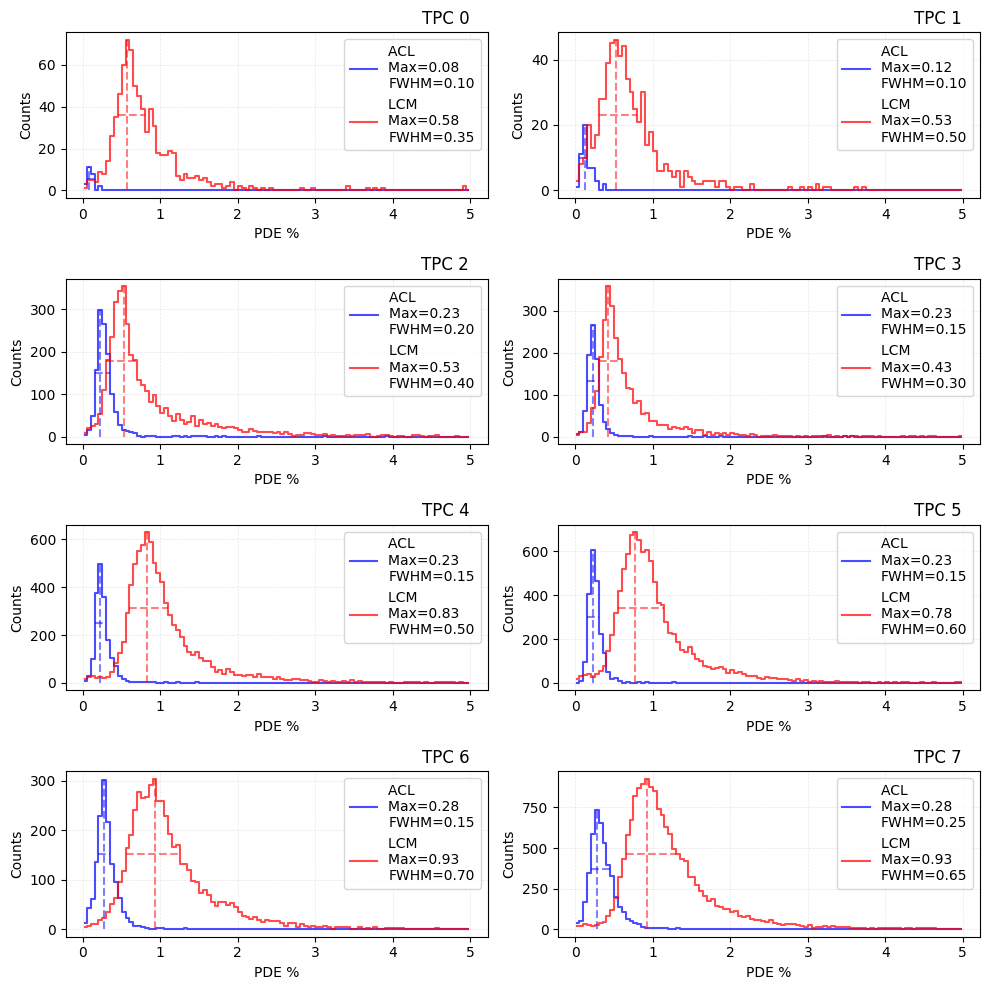

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes = axes.flatten()
mask_acl = det_type_array == 0
mask_lcm = det_type_array == 1

mask0 = (all_pdes != 0.0) & (~np.isnan(all_pdes))
dist_masked = np.where(mask0, all_pdes*100, np.nan)


for tpc_id in range(8):
    ax = axes[tpc_id]
    # masks for this tpc: shape (16,)
    acl_mask = mask_acl[tpc_id]   # shape (16,)
    lcm_mask = mask_lcm[tpc_id]   # shape (16,)

    dist_acl = dist_masked[:, tpc_id, :][:, acl_mask].flatten()  # (536, n_acl)
    dist_lcm = dist_masked[:, tpc_id, :][:, lcm_mask].flatten()  # (536, n_lcm)
    
    # drop nans before histogramming
    dist_acl = dist_acl[~np.isnan(dist_acl)]
    dist_lcm = dist_lcm[~np.isnan(dist_lcm)]

    mpv, fwhm, error_left, error_right, max_height = find_fwhm(dist_acl, bins=np.linspace(0, 5, 101))      
    # label = 'ACL' if mask_acl[tpc_id, det_id] else 'LCM'
    label = f'Max={mpv:.2f} \nFWHM={fwhm:.2f}'
    draw_hist(ax, dist_acl, bins=np.linspace(0,5,101), 
                    label=f'ACL \n{label}',
                    color='blue'
                    )
    ax.vlines(mpv, ymin=0, ymax=max_height, color='blue', linestyle='--', alpha=0.5)
    ax.hlines(0.5*max_height, xmin=mpv-error_left, xmax=mpv + error_right, color='blue', linestyle='--', alpha=0.5)

    mpv, fwhm, error_left, error_right, max_height = find_fwhm(dist_lcm, bins=np.linspace(0, 5, 101))      
    # label = 'ACL' if mask_acl[tpc_id, det_id] else 'LCM'
    label = f'Max={mpv:.2f} \nFWHM={fwhm:.2f}'
    draw_hist(ax, dist_lcm, bins=np.linspace(0,5,101), 
                    label=f'LCM \n{label}',
                    color='red'
                    )
   
    ax.vlines(mpv, ymin=0, ymax=max_height, color='red', linestyle='--', alpha=0.5)
    ax.hlines(0.5*max_height, xmin=mpv-error_left, xmax=mpv + error_right, color='red', linestyle='--', alpha=0.5)


    axes[tpc_id].set_title(f'TPC {tpc_id}', y=1, x=0.9)

for ax in axes:
    ax.set_xlabel('PDE %')
    ax.set_ylabel('Counts')
    ax.grid(True, alpha=0.3)
    # ax.set_xlim(-1, 134)
    ax.legend(loc='upper right')
fig.tight_layout()
plt.show()